# Calculate geometric eigenmodes

As outlined in in [Pang *et al.* (2023)](https://doi.org/10.1038/s41586-023-06098-1), the geometric
 eigenmodes of a brain structure can be obtained by solving the Laplace-Beltrami eigenvalue problem,

$$
\displaystyle \Delta\Psi = -\Lambda\Psi,
$$
 
 where:
 - $\Delta$ denotes the Laplace-Beltrami operator
 - $\Psi$ denotes the set of eigenmodes $\{\psi _1, \psi _2, ...\}$, ordered in ascending spatial frequency
 - $\Lambda$ denotes the set of eigenvalues $\{\lambda _1, \lambda _2, ...\}$, ordered in increasing value

In representing a brain structure as a discrete mesh of $N$ vertices, the above relation becomes a
 generalized eigenvalue problem,

$$
\displaystyle K\Psi = -\Lambda M\Psi,
$$

 where $K$ and $M$ denote the mass and stiffness matrices used by the Finite Element Method.

To calculate geometric eigenmodes of the cortex, we will first initialise an `EigenSolver` with a
 triangular surface mesh and medial wall mask. Since `neuromodes` includes these for human, macaque,
 and marmoset cortices, we can provide them as follows:

In [ ]:
from importlib.resources import files, as_file
from tempfile import TemporaryDirectory
from nsbutils.plotting import plot_surf
from nsbutils.utils import unmask
from numpy import isin
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf, fetch_vol

# Load cortical surface mesh
surf, medmask = fetch_surf()

# Initialise solver with surface
solver = EigenSolver(surf, mask=medmask)

Note that by default, `fetch_surf` will load the human left hemisphere fsLR-32k midthickness
surface.

Next, we can compute eigenmodes and eigenvalues:

In [2]:
solver.solve(100)


Note that we specified the first 100 eigenmodes and eigenvalues, which are then stored in the
 `emodes` and `evals` attributes. To visualize the modes, we can use our sister package `nsbutils`
 to first add our medial wall back in via `unmask`, then pass a few modes to `plot_surf`:

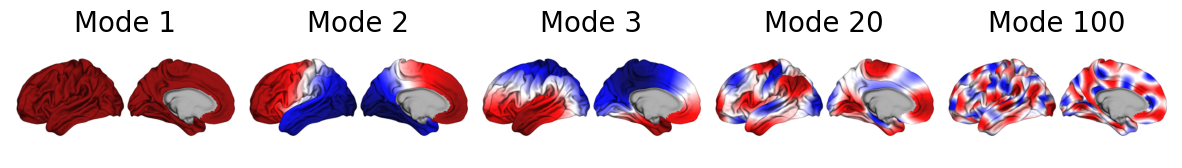

In [3]:
modes_unmasked = unmask(solver.emodes, medmask)

lh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
with as_file(lh_surfpath) as lh_surfpath:
    plot_surf(lh_surfpath, modes_unmasked[:,[0,1,2,19,99]], labels=['Mode 1', 'Mode 2', 'Mode 3', 'Mode 20', 'Mode 100'], cmap='seismic_r')

We can also calculate eigenmodes of a volume structure, such as the left thalamus, which is
 represented as a tetrahedral volume mesh:

In [62]:
# Load thalamic mesh
vol = fetch_vol('thalamus')

# Initialise solver and solve
solver = EigenSolver(vol).solve(100)

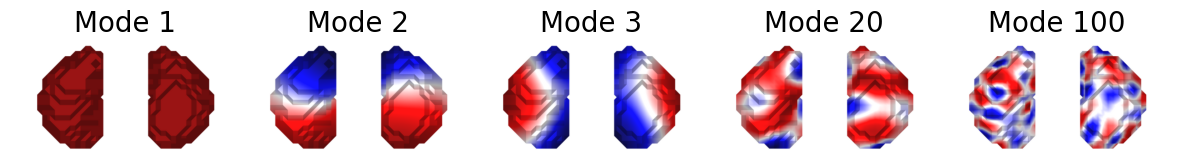

In [65]:
# Extract outer boundary
vol_bound = vol.boundary_tria()
vol_bound.orient_()

# Remove free vertices
vol_bound.rm_free_vertices_()

bound_mask = isin(vol.v, vol_bound.v).all(axis=1)
modes_bound = solver.emodes[bound_mask]

with TemporaryDirectory() as tmpdir:
    # Save to VTK for current nsbutils plotter
    path = f'{tmpdir}/vol_bound.vtk'
    vol_bound.write_vtk(path)

    # Plot
    plot_surf(path, modes_bound[:,[0,1,2,19,99]], labels=['Mode 1', 'Mode 2', 'Mode 3', 'Mode 20', 'Mode 100'], cmap='seismic_r')